# Results analysis (2024 study)

A clean re-analysis of the April 2024 study data. It replaces the work-in-progress `Graphs.ipynb` and fixes these problems:

| Problem in `Graphs.ipynb` | Fix here |
|---|---|
| Time = frames ÷ 30, but the scripts only ran at ~15 fps, so all times were **half** their real value | Time comes from the timestamp logged with every frame |
| Frames with no hand detected were dropped (`parse.py`), shortening trials and occasionally merging two trials | Every frame is kept; "no hand" is recorded as missing |
| One file per pose count was picked arbitrarily, so the **practice run** was used as the 6-pose keyboard block for 4 participants | Each file is labelled from the session timeline; the practice run is excluded |
| Accuracy: test data aligned to its own template and averaged over the whole prompt window (mostly reading or moving) | Test data aligned with the calibration template; pose read from the last frames before the space press |

**Study design** (see the README): each participant chose 6 poses and calibrated them (7 repetitions each). Then, for 2, 4 and 6 poses (in counterbalanced order), they did a **prompt** block (copy the pose shown) followed by a **keyboard** block (type a 47-letter phrase, finding each key's colour-coded pose). Every participant after the first (`KrpKfx`) did a 6-pose keyboard practice run first. **12 participants** took part (Apr 9–22, 2024); `dy2szx` and `0u6vBd` were dry runs of the procedure and are not included.

In [1]:
import re
import datetime as dt
import pathlib
from collections import Counter
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

from register import HandRegister
from norm_class import NormClass

DATA = pathlib.Path('.')
FIG_DIR = DATA / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# Frames averaged, just before the space press, to read the pose a participant was holding.
# An analysis choice: 5 frames is ~0.33 s at the ~15 fps the scripts actually ran at.
# The sensitivity section below shows how the choice affects accuracy.
WINDOW = 5

# The 12 study participants (Apr 9 - Apr 22, 2024), in session order. KrpKfx's data was
# committed as "first trial". dy2szx (Apr 2) and 0u6vBd (Apr 9) were full dry runs of the
# procedure ("full run-through" commits) and are not participants.
PARTICIPANTS = ['KrpKfx', 'uVoAnv', '2iTyoP', '9Z0czI', 'on7sut', 'yX98eE',
                'DO3yNb', 'EOx0vb', 'zUmr0W', '3SePwH', '3H1N53', 'O8gX1A']

In [2]:
# Plot style: one shared look for every figure
COLORS = {'keyboard': '#2a78d6', 'prompt': '#eb6834'}   # validated categorical pair
INK, INK_2, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#b8b7b1', '#e6e5e0', '#fcfcfb'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK_2, 'text.color': INK,
    'xtick.color': INK_2, 'ytick.color': INK_2, 'axes.grid': True, 'axes.axisbelow': True,
    'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 2, 'lines.markersize': 8, 'font.size': 11, 'axes.titlesize': 13,
    'axes.titleweight': 'bold', 'axes.titlelocation': 'left', 'legend.frameon': False,
    'figure.dpi': 110,
})

def mean_ci(values):
    # mean and 95% t-interval half-width across participants
    v = np.asarray(values, dtype=float)
    return v.mean(), stats.t.ppf(0.975, len(v) - 1) * v.std(ddof=1) / np.sqrt(len(v))

## 1. Reading the log files

Every line starting with `{` in a results file is one camera frame: the MediaPipe hand result, the trial status (`-1` = between trials, `-2` = paused, `0`–`5` = the pose being prompted) and a timestamp. Calibration files store the time as pygame ticks (ms); stage 3 files store a `datetime`.

If more than one hand was detected, the side seen most often across the file is used (as in `parse.py`). Frames with no hand get `NaN` landmarks.

In [3]:
RE_STATUS = re.compile(r"'trialStatus': (-?\d+)")
RE_DATETIME = re.compile(r"'time': datetime\.datetime\(([\d, ]+)\)")
RE_TICKS_TIME = re.compile(r"'time': (\d+)\}")
RE_HAND = re.compile(r"display_name='(\w+)'")
RE_LMK = re.compile(r"NormalizedLandmark\(x=([-\d.e]+), y=([-\d.e]+), z=([-\d.e]+)")


@lru_cache(maxsize=None)
def read_frames(path):
    # Returns the header lines plus one row per frame: status, time (s), 63 landmark coords.
    header, status, times, hands = [], [], [], []
    for line in open(path):
        if not line.startswith('{'):
            header.append(line.rstrip('\n'))
            continue
        status.append(int(RE_STATUS.search(line).group(1)))
        m = RE_DATETIME.search(line)
        times.append(dt.datetime(*map(int, m.group(1).split(','))).timestamp() if m
                     else int(RE_TICKS_TIME.search(line).group(1)) / 1000)
        before, _, after = line.partition('hand_landmarks=')
        names = [n.lower() for n in RE_HAND.findall(before)]
        pts = np.array(RE_LMK.findall(after.partition('hand_world_landmarks=')[0]), dtype=float)
        frame = {}
        for i, name in enumerate(names):
            if name not in frame and len(pts) >= 21 * (i + 1):
                frame[name] = pts[21 * i: 21 * (i + 1)].reshape(-1)
        hands.append(frame)

    side = Counter(k for f in hands for k in f).most_common(1)[0][0]
    lmk = np.full((len(hands), 63), np.nan)
    for i, f in enumerate(hands):
        if side in f:
            lmk[i] = f[side]
    return dict(header='\n'.join(header), status=np.array(status), time=np.array(times), lmk=lmk)


def split_trials(status):
    # (start, end) frame indices of each run of consecutive frames showing one prompted pose
    active = status >= 0
    edges = np.diff(np.r_[0, active.astype(int), 0])
    starts, ends = np.where(edges == 1)[0], np.where(edges == -1)[0]
    return [(s, e) for s, e in zip(starts, ends) if len(set(status[s:e])) == 1]

## 2. Which file is which condition

Result files are numbered in the order they were created (`<id>_0.txt`, `<id>_1.txt`, ...), and the number does not identify the condition. Here each completed run is placed on the participant's timeline using its `Trial Begin` time:

- A keyboard run that starts before the participant's first prompt run is the **practice run**, and is excluded.
- Aborted runs (no `Trial End`) are ignored.
- **Round** = whether that pose count was the participant's 1st, 2nd or 3rd block.

The table is checked against the orders recorded in `Graphs.ipynb`.

In [4]:
def run_info(path):
    text = open(path).read()
    return dict(path=path,
                num_pose=len(re.search(r'POSES: \[(.*?)\]', text).group(1).split(',')),
                begin=pd.Timestamp(re.search(r'Trial Begin : ([\d\- :.]+)', text).group(1).strip()),
                complete='Trial End' in text)

runs = []
for pid in PARTICIPANTS:
    info = {task: sorted((run_info(p) for p in (DATA / f'{task}-results').glob(f'{pid}_*.txt')),
                         key=lambda r: r['begin']) for task in ('prompt', 'keyboard')}
    first_prompt = min(r['begin'] for r in info['prompt'] if r['complete'])
    for task, task_runs in info.items():
        for r in task_runs:
            if not r['complete']:
                continue
            practice = task == 'keyboard' and r['begin'] < first_prompt
            runs.append(dict(pid=pid, task=task, num_pose=r['num_pose'], begin=r['begin'],
                             practice=practice, file=r['path'].name))
runs = pd.DataFrame(runs)
study = runs[~runs.practice].copy()

# One run per participant x task x pose count, and the pose-count order is the same for both tasks
assert not study.duplicated(['pid', 'task', 'num_pose']).any()
assert (study.groupby(['pid', 'task']).size() == 3).all()
order = {pid: list(g.sort_values('begin').num_pose) for pid, g in study[study.task == 'prompt'].groupby('pid')}
for pid, g in study[study.task == 'keyboard'].groupby('pid'):
    assert list(g.sort_values('begin').num_pose) == order[pid], pid
study['round'] = [order[p].index(n) + 1 for p, n in zip(study.pid, study.num_pose)]

# Cross-check with the orders written down in Graphs.ipynb
graphs_2024_orders = {'KrpKfx': [4, 2, 6], 'uVoAnv': [2, 4, 6], '2iTyoP': [6, 2, 4], '9Z0czI': [2, 6, 4],
                      'on7sut': [4, 6, 2], 'yX98eE': [6, 4, 2], 'DO3yNb': [2, 4, 6], 'EOx0vb': [4, 2, 6],
                      'zUmr0W': [6, 2, 4], '3H1N53': [2, 6, 4], '3SePwH': [4, 6, 2], 'O8gX1A': [6, 4, 2]}
assert order == graphs_2024_orders

summary = (study.pivot_table(index='pid', columns=['task', 'num_pose'], values='file', aggfunc='first')
           .reindex(PARTICIPANTS))
summary.insert(0, 'order', [' → '.join(map(str, order[p])) for p in summary.index])
summary.insert(1, 'practice run', [', '.join(runs[(runs.pid == p) & runs.practice].file) or '—' for p in summary.index])
summary

task          order  practice run      keyboard                              \
num_pose                                      2             4             6   
pid                                                                           
KrpKfx    4 → 2 → 6             —  KrpKfx_1.txt  KrpKfx_0.txt  KrpKfx_2.txt   
uVoAnv    2 → 4 → 6             —  uVoAnv_1.txt  uVoAnv_2.txt  uVoAnv_3.txt   
2iTyoP    6 → 2 → 4  2iTyoP_0.txt  2iTyoP_2.txt  2iTyoP_3.txt  2iTyoP_1.txt   
9Z0czI    2 → 6 → 4             —  9Z0czI_1.txt  9Z0czI_3.txt  9Z0czI_2.txt   
on7sut    4 → 6 → 2  on7sut_0.txt  on7sut_3.txt  on7sut_1.txt  on7sut_2.txt   
yX98eE    6 → 4 → 2             —  yX98eE_3.txt  yX98eE_2.txt  yX98eE_1.txt   
DO3yNb    2 → 4 → 6             —  DO3yNb_1.txt  DO3yNb_2.txt  DO3yNb_3.txt   
EOx0vb    4 → 2 → 6  EOx0vb_0.txt  EOx0vb_2.txt  EOx0vb_1.txt  EOx0vb_3.txt   
zUmr0W    6 → 2 → 4  zUmr0W_0.txt  zUmr0W_2.txt  zUmr0W_3.txt  zUmr0W_1.txt   
3SePwH    4 → 6 → 2             —  3SePwH_3.txt  3SePwH_1.txt  3SePwH_2.txt   
3H1N53    2 → 6 → 4             —  3H1N53_1.txt  3H1N53_3.txt  3H1N53_2.txt   
O8gX1A    6 → 4 → 2  O8gX1A_0.txt  O8gX1A_3.txt  O8gX1A_2.txt  O8gX1A_1.txt   

task            prompt                              
num_pose             2             4             6  
pid                                                 
KrpKfx    KrpKfx_1.txt  KrpKfx_0.txt  KrpKfx_2.txt  
uVoAnv    uVoAnv_0.txt  uVoAnv_1.txt  uVoAnv_2.txt  
2iTyoP    2iTyoP_1.txt  2iTyoP_2.txt  2iTyoP_0.txt  
9Z0czI    9Z0czI_0.txt  9Z0czI_2.txt  9Z0czI_1.txt  
on7sut    on7sut_2.txt  on7sut_0.txt  on7sut_1.txt  
yX98eE    yX98eE_2.txt  yX98eE_1.txt  yX98eE_0.txt  
DO3yNb    DO3yNb_0.txt  DO3yNb_1.txt  DO3yNb_2.txt  
EOx0vb    EOx0vb_1.txt  EOx0vb_0.txt  EOx0vb_2.txt  
zUmr0W    zUmr0W_1.txt  zUmr0W_2.txt  zUmr0W_0.txt  
3SePwH    3SePwH_2.txt  3SePwH_0.txt  3SePwH_1.txt  
3H1N53    3H1N53_0.txt  3H1N53_2.txt  3H1N53_1.txt  
O8gX1A    O8gX1A_2.txt  O8gX1A_1.txt  O8gX1A_0.txt

## 3. Calibration classifiers

For each participant, as in `train.py` and `stage2-visual.ipynb`: average each calibration trial's landmarks, align them to a template hand built from the palm points (`HandRegister`), and fit `NormClass` (nearest class mean with a shared variance). The difference: the **same fitted alignment** is reused on that participant's stage 3 data, so both sets are in the same coordinates.

The cross-validated accuracy on calibration data alone (3 folds, all 6 poses) is shown for reference.

In [5]:
from sklearn.model_selection import StratifiedKFold

def trial_mean(frames, start, end, last=None):
    x = frames['lmk'][start:end]
    x = x[~np.isnan(x[:, 0])]
    if last is not None:
        x = x[-last:]
    return x.mean(axis=0) if len(x) else np.full(63, np.nan)

calibration = {}
cal_rows = []
for pid in PARTICIPANTS:
    frames = read_frames(DATA / 'calibration-results' / f'{pid}.txt')
    trials = split_trials(frames['status'])
    x = np.array([trial_mean(frames, s, e) for s, e in trials])
    y = np.array([frames['status'][s] for s, _ in trials])
    keep = ~np.isnan(x[:, 0])
    x, y = x[keep], y[keep]

    reg = HandRegister()
    reg.fit(x.T)
    x_reg = reg.transform(x.T).T
    clf = NormClass()
    clf.fit(x_reg, y)
    calibration[pid] = (reg, clf)

    pred = np.empty_like(y)
    for tr, te in StratifiedKFold(3, shuffle=True, random_state=0).split(x_reg, y):
        fold_clf = NormClass()
        fold_clf.fit(x_reg[tr], y[tr])
        pred[te] = fold_clf.predict(x_reg[te])
    cal_rows.append(dict(pid=pid, trials=len(y), cv_accuracy=(pred == y).mean()))

cal_summary = pd.DataFrame(cal_rows).set_index('pid')
cal_summary.style.format({'cv_accuracy': '{:.0%}'})

,trials,cv_accuracy
pid,,
KrpKfx,42,98%
uVoAnv,42,71%
2iTyoP,42,100%
9Z0czI,42,100%
on7sut,42,88%
yX98eE,42,100%
DO3yNb,42,100%
EOx0vb,42,95%
zUmr0W,42,93%


## 4. One row per stage 3 trial

For every prompt shown:
- **response time** = time from the prompt appearing to the space press (the first frame of the following break);
- **predicted pose** = the calibration classifier applied to the mean of the last `WINDOW` hand-detected frames before the space press. The classifier only chooses among the poses in use in that block (a system would know which poses are active).

In [6]:
def classify(pid, x, active_poses):
    reg, clf = calibration[pid]
    log_prob = clf.predict_log_prob(reg.transform(x.T).T)
    log_prob[:, ~np.isin(clf.class_label, active_poses)] = -np.inf
    return clf.class_label[log_prob.argmax(axis=1)]

def score_run(row, window=WINDOW):
    frames = read_frames(DATA / f'{row.task}-results' / row.file)
    active_poses = [int(v) for v in re.search(r'POSES: \[(.*?)\]', frames['header']).group(1).split(',')]
    trials = split_trials(frames['status'])
    ends_time = [frames['time'][e] if e < len(frames['time']) else np.nan for _, e in trials]
    x = np.array([trial_mean(frames, s, e, last=window) for s, e in trials])
    no_hand = np.isnan(x[:, 0])
    pred = np.full(len(trials), -1)
    if (~no_hand).any():
        pred[~no_hand] = classify(row.pid, x[~no_hand], active_poses)
    target = np.array([frames['status'][s] for s, _ in trials])
    return pd.DataFrame(dict(
        pid=row.pid, task=row.task, num_pose=row.num_pose, round=row['round'],
        trial=np.arange(len(trials)), target=target, predicted=pred, no_hand=no_hand,
        correct=pred == target,
        response_time=np.array(ends_time) - frames['time'][[s for s, _ in trials]],
        frames=[e - s for s, e in trials]))

trials = pd.concat([score_run(r) for _, r in study.iterrows()], ignore_index=True)
print(f"{len(trials)} trials from {trials.pid.nunique()} participants "
      f"({len(trials) / len(study):.0f} per block, 47 expected)")
print(f"trials with no hand detected in the window: {trials.no_hand.sum()}")
print(f"effective frame rate: {(trials.frames / trials.response_time).median():.1f} fps")
trials.head()

3384 trials from 12 participants (47 per block, 47 expected)
trials with no hand detected in the window: 0
effective frame rate: 15.0 fps


,pid,task,num_pose,round,trial,target,predicted,no_hand,correct,response_time,frames
0,KrpKfx,prompt,4,1,0,5,5,False,True,1.199097,18
1,KrpKfx,prompt,4,1,1,5,5,False,True,1.067691,16
2,KrpKfx,prompt,4,1,2,1,1,False,True,0.869566,13
3,KrpKfx,prompt,4,1,3,5,5,False,True,1.026113,16
4,KrpKfx,prompt,4,1,4,0,1,False,False,0.879473,13


## 5. Response time

Each participant's **median** response time per block is used (a few long pauses would otherwise dominate a mean), then averaged across participants. Error bars are 95% confidence intervals across participants; thin grey lines are individual participants.

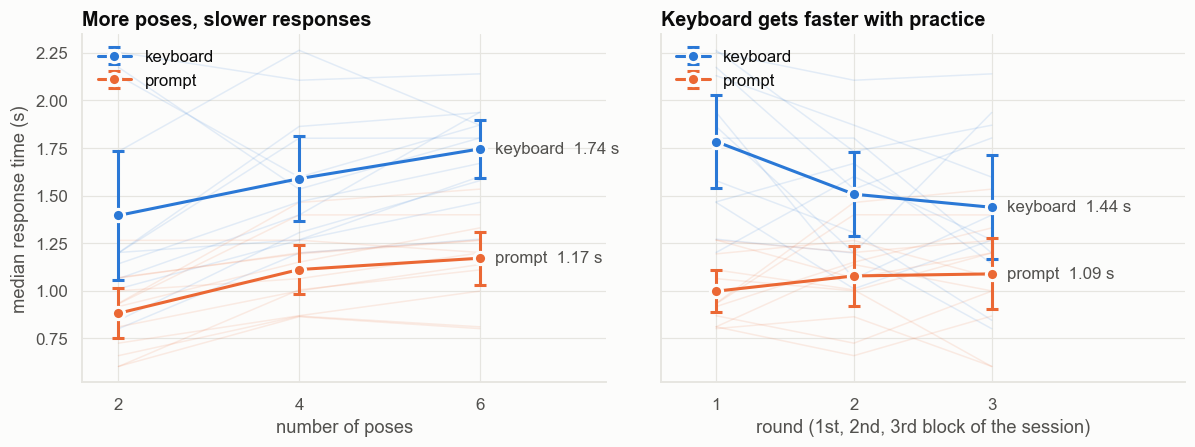

In [7]:
block = (trials.groupby(['pid', 'task', 'num_pose', 'round'])
         .agg(median_time=('response_time', 'median'), accuracy=('correct', 'mean'))
         .reset_index())

def plot_by(ax, df, x, y, xticks, ylabel, fmt, chance=None, end_labels=True, legend_loc='upper left'):
    for task, sub in df.groupby('task'):
        for _, p in sub.groupby('pid'):
            ax.plot(p.sort_values(x)[x], p.sort_values(x)[y], color=COLORS[task], alpha=0.12, lw=1)
        agg = [(v, *mean_ci(g[y])) for v, g in sub.groupby(x)]
        xs, means, cis = zip(*agg)
        ax.errorbar(xs, means, yerr=cis, color=COLORS[task], marker='o', capsize=4,
                    markeredgecolor=SURFACE, markeredgewidth=2, label=task, zorder=3)
        if end_labels:
            ax.annotate(f'{task}  {fmt(means[-1])}', (xs[-1], means[-1]), xytext=(10, 0),
                        textcoords='offset points', va='center', color=INK_2)
    if chance is not None:
        ax.plot(xticks, chance, color=MUTED, ls='--', lw=1.5, label='chance')
    ax.set_xticks(xticks)
    ax.set_xlim(xticks[0] - 0.4, xticks[-1] + (1.4 if end_labels else 0.4))
    ax.set_ylabel(ylabel)
    ax.legend(loc=legend_loc)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
plot_by(axes[0], block, 'num_pose', 'median_time', [2, 4, 6], 'median response time (s)', lambda v: f'{v:.2f} s')
axes[0].set_xlabel('number of poses')
axes[0].set_title('More poses, slower responses')
plot_by(axes[1], block, 'round', 'median_time', [1, 2, 3], '', lambda v: f'{v:.2f} s')
axes[1].set_xlabel('round (1st, 2nd, 3rd block of the session)')
axes[1].set_title('Keyboard gets faster with practice')
fig.tight_layout()
fig.savefig(FIG_DIR / 'response_time.png', dpi=150)
plt.show()

In [8]:
time_table = (block.groupby(['task', 'num_pose']).median_time
              .apply(lambda v: '{:.2f} s ± {:.2f}'.format(*mean_ci(v))).unstack())
time_table.columns = [f'{c} poses' for c in time_table.columns]
time_table

,2 poses,4 poses,6 poses
task,,,
keyboard,1.40 s ± 0.34,1.59 s ± 0.22,1.74 s ± 0.15
prompt,0.88 s ± 0.13,1.11 s ± 0.13,1.17 s ± 0.14


### Separating pose count from practice

Because the order was counterbalanced, pose count and round can be estimated together. The model below fits each block's median time with pose count and round as categories, plus a separate baseline for each participant. Coefficients are **seconds relative to 2 poses / round 1**.

In [9]:
effects = []
for task, sub in block.groupby('task'):
    fit = smf.ols('median_time ~ C(num_pose) + C(round) + C(pid)', data=sub).fit()
    ci = fit.conf_int()
    for term in [t for t in fit.params.index if t.startswith(('C(num_pose)', 'C(round)'))]:
        label = term.replace('C(num_pose)[T.', '').replace('C(round)[T.', 'round ').rstrip(']')
        label = label + ' poses' if not label.startswith('round') else label
        effects.append(dict(task=task, effect=label, seconds=fit.params[term],
                            ci_low=ci.loc[term, 0], ci_high=ci.loc[term, 1], p=fit.pvalues[term]))
effects = pd.DataFrame(effects).set_index(['task', 'effect'])
effects.style.format({'seconds': '{:+.2f}', 'ci_low': '{:+.2f}', 'ci_high': '{:+.2f}', 'p': '{:.3f}'})

## 6. Accuracy

Chance is 1 / number of poses (dashed line).

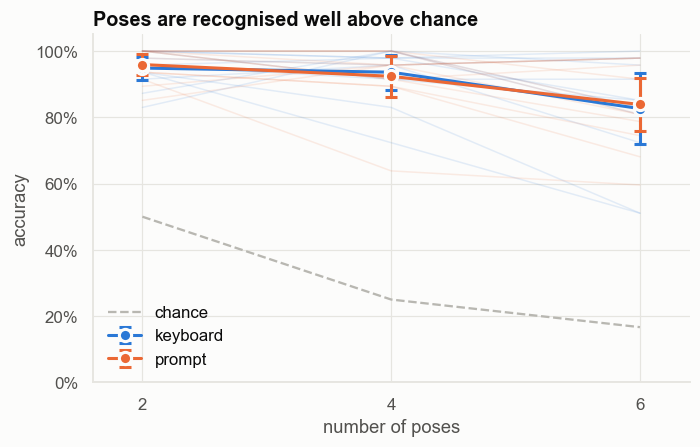

,2 poses,4 poses,6 poses
task,,,
keyboard,95% ± 3%,94% ± 5%,83% ± 11%
prompt,96% ± 3%,92% ± 6%,84% ± 8%


In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
plot_by(ax, block, 'num_pose', 'accuracy', [2, 4, 6], 'accuracy', lambda v: f'{v:.0%}',
        chance=[1 / 2, 1 / 4, 1 / 6], end_labels=False, legend_loc='lower left')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.set_xlabel('number of poses')
ax.set_title('Poses are recognised well above chance')
fig.tight_layout()
fig.savefig(FIG_DIR / 'accuracy.png', dpi=150)
plt.show()

acc_table = (block.groupby(['task', 'num_pose']).accuracy
             .apply(lambda v: '{:.0%} ± {:.0%}'.format(*mean_ci(v))).unstack())
acc_table.columns = [f'{c} poses' for c in acc_table.columns]
acc_table

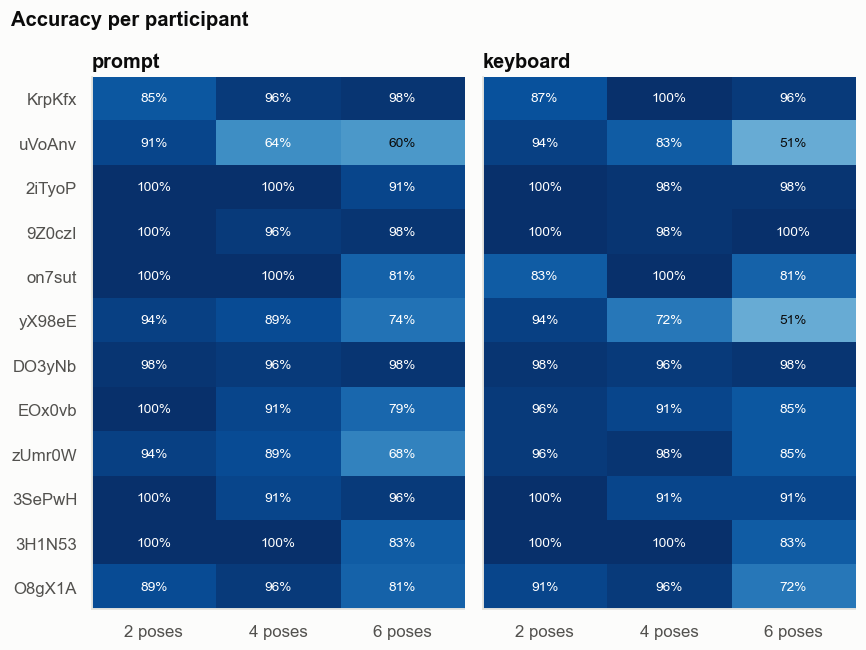

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)
for ax, task in zip(axes, ['prompt', 'keyboard']):
    grid = block[block.task == task].pivot(index='pid', columns='num_pose', values='accuracy').reindex(PARTICIPANTS)
    im = ax.imshow(grid.values, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    for (i, j), v in np.ndenumerate(grid.values):
        ax.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=9, color='white' if v > 0.6 else INK)
    ax.set_xticks(range(3), [f'{c} poses' for c in grid.columns])
    ax.set_yticks(range(len(grid)), grid.index)
    ax.set_title(task)
    ax.grid(False)
fig.suptitle('Accuracy per participant', x=0.02, ha='left', fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'accuracy_per_participant.png', dpi=150)
plt.show()

### How much does the reading window matter?

`WINDOW` is an analysis choice. Here accuracy is recomputed using the last 1, 3, 5, 10 and 20 hand-detected frames before the space press, and the whole prompt window (what `Graphs.ipynb` averaged over). Taking the whole window sharply lowers accuracy because it includes reading and moving between poses.

In [12]:
sens = []
for w in [1, 3, 5, 10, 20, None]:
    t = pd.concat([score_run(r, window=w) for _, r in study.iterrows()], ignore_index=True)
    acc = t.groupby(['pid', 'task', 'num_pose']).correct.mean().groupby(['task', 'num_pose']).mean()
    sens.append(acc.rename('whole window' if w is None else f'last {w}'))
sens = pd.concat(sens, axis=1)
sens.style.format('{:.0%}')

## 7. Speed and accuracy together

Is it worth using more poses? More poses carry more information per gesture, but are slower and less accurate. The **information transfer rate** (Wolpaw et al., 2002) combines both: bits per selection from the number of poses and accuracy, divided by time per selection. Time here is the median response time only; the fixed 2 s break between prompts is part of the study design and is left out.

In [13]:
def wolpaw_bits(n, p):
    p = np.clip(p, 1e-9, 1 - 1e-9)
    bits = np.log2(n) + p * np.log2(p) + (1 - p) * np.log2((1 - p) / (n - 1))
    return np.where(p <= 1 / n, 0, bits)

block['bits_per_min'] = wolpaw_bits(block.num_pose, block.accuracy) * 60 / block.median_time
overview = block.groupby(['task', 'num_pose']).agg(
    accuracy=('accuracy', 'mean'), median_time=('median_time', 'mean'), bits_per_min=('bits_per_min', 'mean'))
overview.style.format({'accuracy': '{:.0%}', 'median_time': '{:.2f} s', 'bits_per_min': '{:.0f}'})

## Notes and limitations

- **Response time includes the experimenter.** Trials advance on a space press; the time is from prompt to that press, not to the moment the hand reached the pose.
- **The accuracy is offline.** Nothing was classified live in 2024. These numbers estimate how a live system trained on each participant's calibration would have done.
- **Keyboard trials repeat.** Every participant typed the same phrase with the same seeded colour assignments, and the phrase appears in all three keyboard blocks.
- **Sample:** 12 participants (`O8gX1A` is the same person as `OLgtIf`, who was calibrated twice). Not included: the pilot sessions (`jtdawc`, Feb–Mar), the two full dry runs (`dy2szx`, `0u6vBd`) and incomplete sessions.